In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/archive (4).zip")


In [ ]:
df.head()

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200


In [ ]:
df.tail()

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
219698,219699,Round,E,VS1,10.65,Excellent,GIA,Excellent,Excellent,unknown,...,8.66,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,1210692
219699,219700,Radiant,unknown,VS2,5.17,unknown,GIA,Very Good,Very Good,unknown,...,5.71,TK,XTK,unknown,NaN,Green,unknown,NaN,Fancy Light,1292500
219700,219701,Round,E,VS1,18.07,Excellent,GIA,Excellent,Excellent,unknown,...,10.20,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,1315496
219701,219702,Princess,unknown,SI2,0.90,unknown,GIA,Good,Good,unknown,...,3.47,XTN,VTK,unknown,Faint,Red,unknown,unknown,Fancy,1350000
219702,219703,Pear,unknown,VVS2,10.03,unknown,GIA,Very Good,Excellent,unknown,...,7.39,unknown,unknown,unknown,NaN,Yellow,unknown,unknown,Fancy Vivid,1449881


In [ ]:
df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219703 entries, 0 to 219702
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   219703 non-null  int64  
 1   cut                          219703 non-null  object 
 2   color                        219703 non-null  object 
 3   clarity                      219703 non-null  object 
 4   carat_weight                 219703 non-null  float64
 5   cut_quality                  219703 non-null  object 
 6   lab                          219703 non-null  object 
 7   symmetry                     219703 non-null  object 
 8   polish                       219703 non-null  object 
 9   eye_clean                    219703 non-null  object 
 10  culet_size                   219703 non-null  object 
 11  culet_condition              219703 non-null  object 
 12  depth_percent                219703 non-null  float64
 13 

,Unnamed: 0,carat_weight,depth_percent,table_percent,meas_length,meas_width,meas_depth,total_sales_price
count,219703.000000,219703.000000,219703.000000,219703.000000,219703.000000,219703.000000,219703.000000,2.197030e+05
mean,109851.747418,0.755176,61.683768,57.747585,5.548853,5.135626,3.285699,6.908062e+03
std,63423.264419,0.845894,9.915266,9.959928,1.763924,1.374529,2.054822,2.595949e+04
min,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+02
25%,54925.500000,0.310000,61.200000,57.000000,4.350000,4.310000,2.680000,9.580000e+02
50%,109852.000000,0.500000,62.400000,58.000000,5.060000,4.800000,3.030000,1.970000e+03
75%,164777.500000,1.000000,63.500000,60.000000,6.350000,5.700000,3.630000,5.207000e+03
max,219703.000000,19.350000,98.700000,94.000000,93.660000,62.300000,76.300000,1.449881e+06


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
cut,0
color,0
clarity,0
carat_weight,0
cut_quality,0
lab,0
symmetry,0
polish,0
eye_clean,0


In [ ]:
df = df.dropna()


In [ ]:
df.duplicated().sum()


np.int64(0)

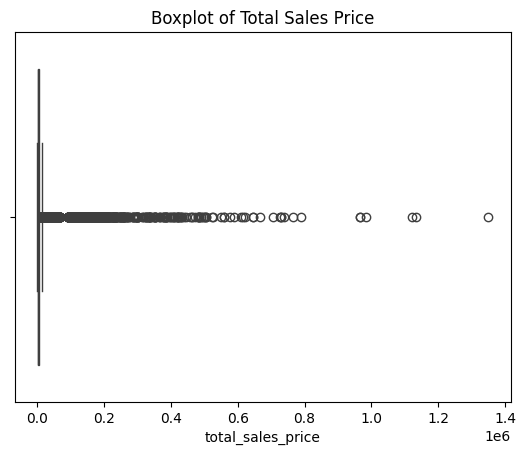

In [ ]:
sns.boxplot(x=df["total_sales_price"])

plt.title("Boxplot of Total Sales Price")
plt.show()

In [ ]:
Q1 = df["total_sales_price"].quantile(0.25)
Q3 = df["total_sales_price"].quantile(0.75)
print(Q1)
print(Q3)

966.0
5641.0


In [ ]:
IQR = Q3 - Q1
print(IQR)

4675.0


In [ ]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)

-6046.5
12653.5


In [ ]:
outliers = df[(df["total_sales_price"] < lower_limit) |
              (df["total_sales_price"] > upper_limit)]

outliers.shape

(8828, 26)

In [ ]:
df = df[(df["total_sales_price"] >= lower_limit) &
        (df["total_sales_price"] <= upper_limit)]
print(df)

        Unnamed: 0    cut color clarity  carat_weight cut_quality  lab  \
26              26  Round     E    VVS1          0.09   Very Good  IGI   
30              30  Round     E    VVS1          0.09   Very Good  IGI   
36              36  Round     G    VVS2          0.10   Very Good  IGI   
37              37  Round     G    VVS2          0.10   Very Good  IGI   
43              43  Round     J      I1          0.35   Excellent  IGI   
...            ...    ...   ...     ...           ...         ...  ...   
196025      196026  Round     E     SI2          1.51   Very Good  GIA   
196027      196028  Round     E     VS2          1.22   Excellent  GIA   
196029      196030  Round     L    VVS1          2.01   Excellent  IGI   
196033      196034  Round     H     VS2          1.51   Excellent  IGI   
196035      196036  Round     K    VVS1          1.58   Excellent  GIA   

         symmetry     polish eye_clean  ... meas_depth girdle_min  girdle_max  \
26      Very Good  Very Good  

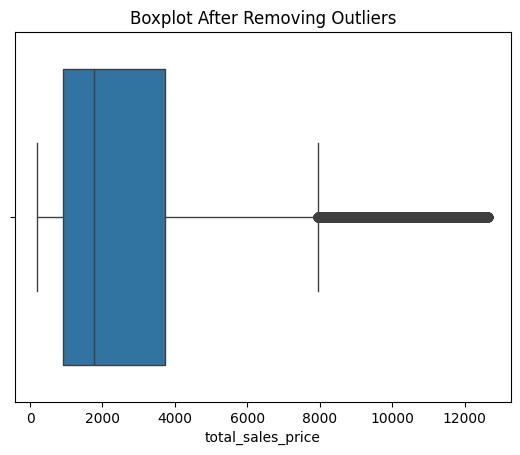

In [ ]:
sns.boxplot(x=df["total_sales_price"])
plt.title("Boxplot After Removing Outliers")
plt.show()

In [ ]:
df.select_dtypes(include=np.number).columns

Index(['Unnamed: 0', 'carat_weight', 'depth_percent', 'table_percent',
       'meas_length', 'meas_width', 'meas_depth', 'total_sales_price'],
      dtype='object')

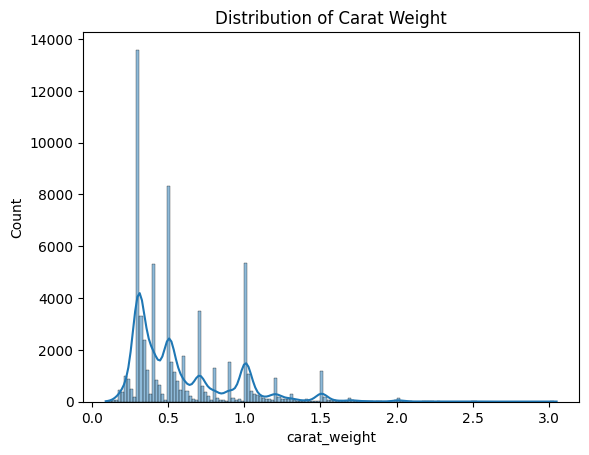

In [ ]:
sns.histplot(df["carat_weight"], kde=True)
plt.title("Distribution of Carat Weight")
plt.show()

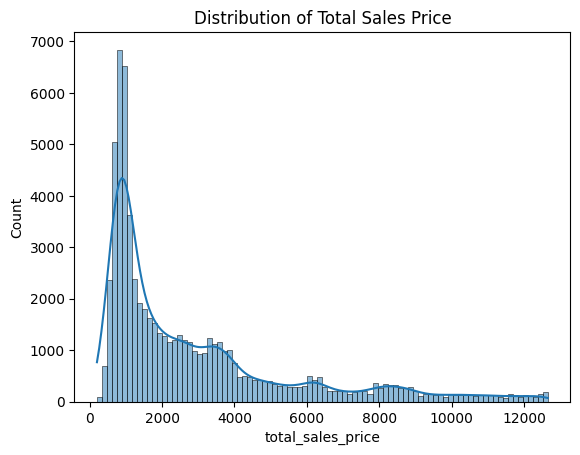

In [ ]:
sns.histplot(df["total_sales_price"], kde=True)
plt.title("Distribution of Total Sales Price")
plt.show()


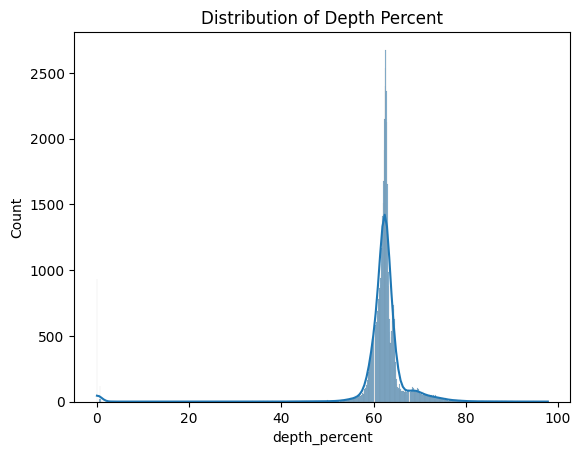

In [ ]:
sns.histplot(df["depth_percent"], kde=True)
plt.title("Distribution of Depth Percent")
plt.show()

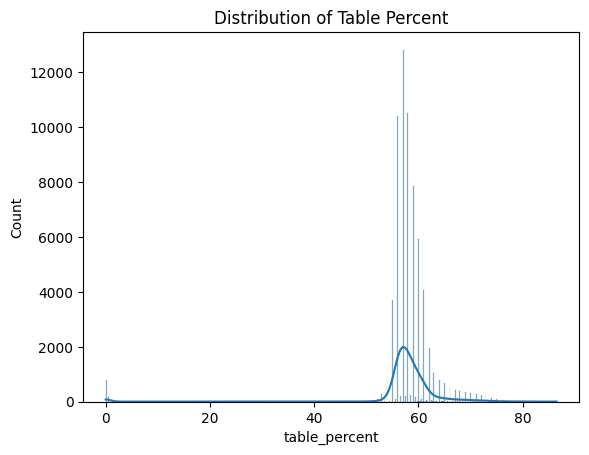

In [ ]:
sns.histplot(df["table_percent"], kde=True)
plt.title("Distribution of Table Percent")
plt.show()

In [ ]:
df.select_dtypes(include="object").columns

Index(['cut', 'color', 'clarity', 'cut_quality', 'lab', 'symmetry', 'polish',
       'eye_clean', 'culet_size', 'culet_condition', 'girdle_min',
       'girdle_max', 'fluor_color', 'fluor_intensity',
       'fancy_color_dominant_color', 'fancy_color_secondary_color',
       'fancy_color_overtone', 'fancy_color_intensity'],
      dtype='object')

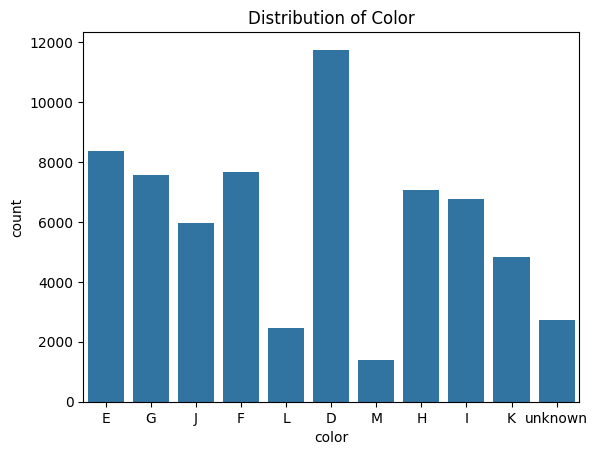

In [ ]:
sns.countplot(x="color", data=df)
plt.title("Distribution of Color")
plt.show()

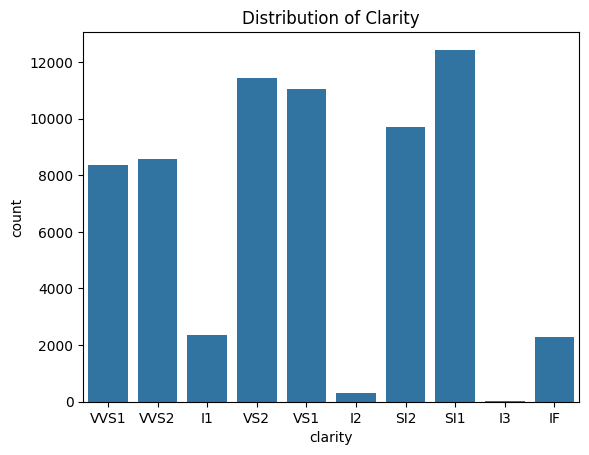

In [ ]:
sns.countplot(x="clarity", data=df)
plt.title("Distribution of Clarity")
plt.show()

In [ ]:
df["total_sales_price"].mean()

np.float64(2876.311550311866)

In [ ]:
df["total_sales_price"].median()

1758.0

In [ ]:
df["total_sales_price"].mode()

,total_sales_price
0,832


In [ ]:
df["total_sales_price"].std()

2718.1604691890934

In [ ]:
df["total_sales_price"].var()

7388396.336262272

In [ ]:
df["total_sales_price"].skew()

np.float64(1.6091686252047745)

In [ ]:
df["total_sales_price"].kurt()

np.float64(1.9714945172376472)

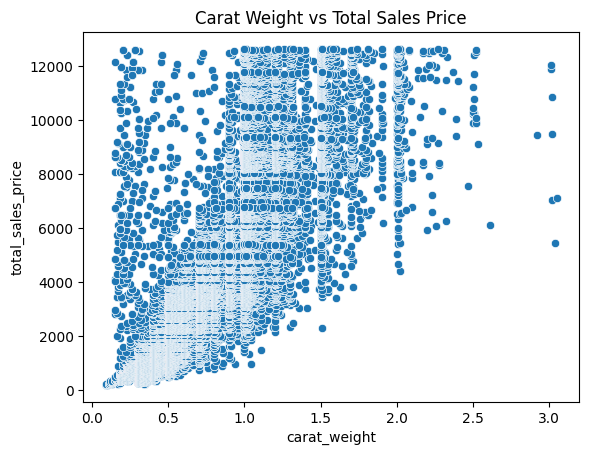

In [ ]:
sns.scatterplot(x="carat_weight",
               y="total_sales_price",
               data=df)
plt.title("Carat Weight vs Total Sales Price")
plt.show()

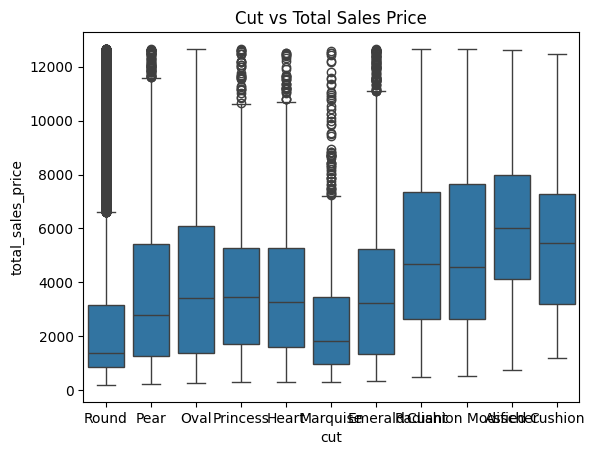

In [ ]:
sns.boxplot(x="cut",
           y="total_sales_price",
           data=df)
plt.title("Cut vs Total Sales Price")
plt.show()

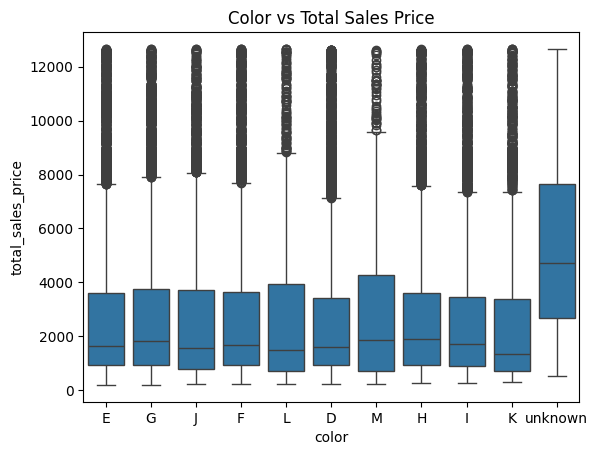

In [ ]:
sns.boxplot(x="color",
           y="total_sales_price",
           data=df)
plt.title("Color vs Total Sales Price")
plt.show()

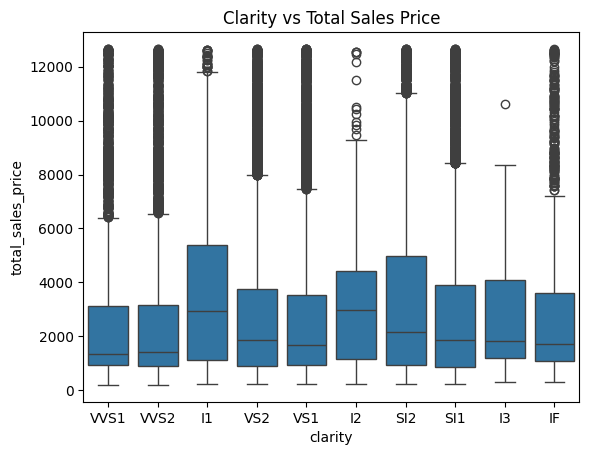

In [ ]:
sns.boxplot(x="clarity",
           y="total_sales_price",
           data=df)
plt.title("Clarity vs Total Sales Price")
plt.show()

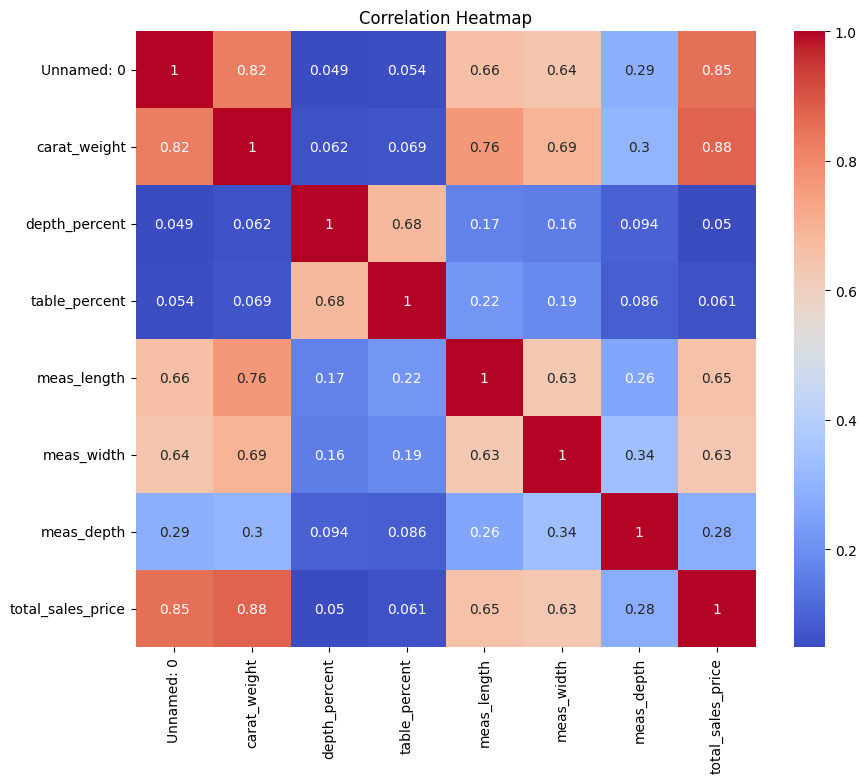

In [ ]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,
           annot=True,
           cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()